# Kalman Task Visualization (Orhan & Ma Kalman RNN)

Sample the Kalman Filtering Task and visualize how Target, Gain, Expected rate, and population spikes form the RNN input.

Domain terms: **Trial**, **Batch**, **Batch internals**, **Target**, **Gain**, **Expected rate**, **Population count**, **Instantaneous population estimate**, **Opt mean**, **Opt variance** — see `CONTEXT.md`.

In [9]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %cd /content/kalnet
    %pip install -e .
else:
    #update for your local path
    %cd /home/jacob/kalnet

/home/jacob/kalnet


In [10]:
import matplotlib.pyplot as plt
import numpy as np

from paper_pytorch.task import KalmanFilteringTask

plt.rcParams.update(
    {
        "figure.figsize": (8, 3.5),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
    }
)

## Sample and visualize the task

Each **Trial** is a length-`stim_dur` sequence. The hidden **Target** `s` and **Gain** determine each neuron's **Expected rate**; Poisson sampling then produces the population spike counts that are the RNN's only input. Optional **Batch internals** let us visualize that generation process and the optimal Kalman filter's estimate.

In [11]:
task = KalmanFilteringTask(
    batch_size=8,
    n_in=50,
    stim_dur=25,
    tr_cond="all_gains",
    seed=0,
)
batch = task.sample(include_internals=True)
assert batch.internals is not None
print(
    f"input {batch.input.shape}, target {batch.target.shape}, "
    f"opt_mean {batch.opt_mean.shape}"
)

trial_idx = 0
t = np.arange(batch.target.shape[1])
phi = task.phi
s = batch.target[trial_idx, :, 0]
m = batch.opt_mean[trial_idx, :, 0]
spikes = batch.input[trial_idx]  # (T, n_in)
gain = batch.internals.gain[trial_idx, :, 0]
expected_rate = batch.internals.expected_rate[trial_idx]
opt_var = batch.internals.opt_var[trial_idx, :, 0]

population_count = spikes.sum(axis=1)
weighted_sum = spikes @ phi
population_estimate = np.full_like(s, np.nan)
np.divide(
    weighted_sum,
    population_count,
    out=population_estimate,
    where=population_count > 0,
)

# Single-timestep likelihood width for Gaussian tuning + Poisson noise:
# var = sigtc_sq / (total spike count). Shrinks as more spikes arrive.
population_sd = np.full_like(s, np.nan)
np.divide(
    task.sigtc_sq,
    population_count,
    out=population_sd,
    where=population_count > 0,
)
population_sd = np.sqrt(population_sd)

selected_times = [
    int(np.argmin(gain)),
    int(np.argmin(np.abs(gain - np.median(gain)))),
    int(np.argmax(gain)),
]
selected_labels = ["lowest", "median", "highest"]

input (8, 25, 50), target (8, 25, 1), opt_mean (8, 25, 1)


### A. How Target and Gain create the RNN input

At each selected timestep, Target `s_t` centers a Gaussian profile over neurons' preferred stimuli and Gain `g_t` scales it. The profile is the Expected rate; the bars are one Poisson sample from it.

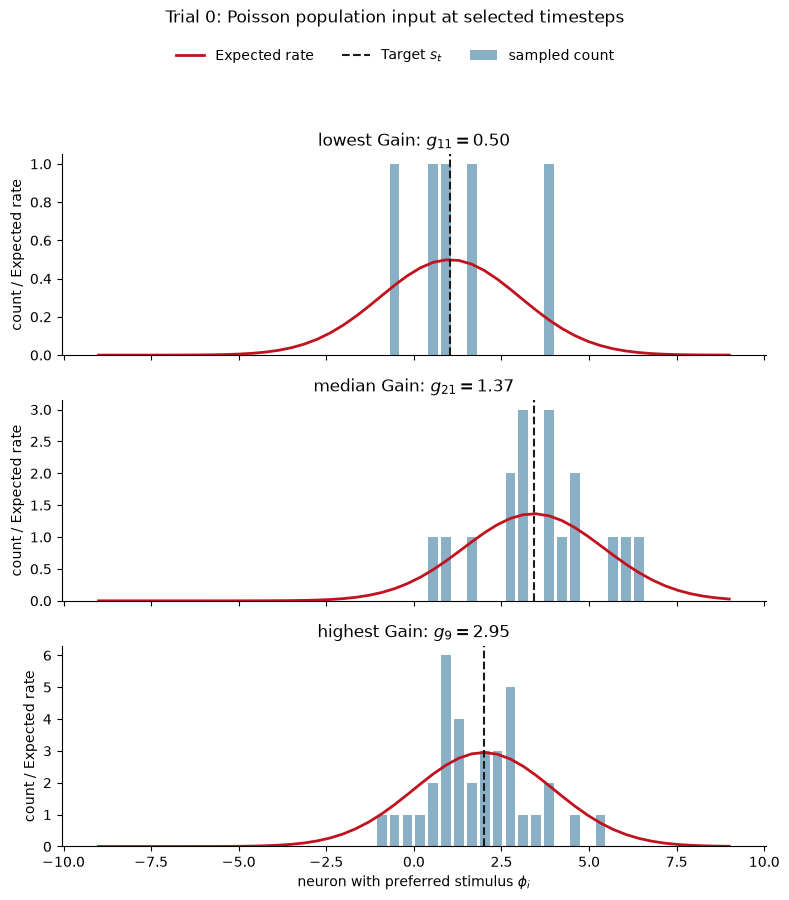

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
for ax, tt, gain_label in zip(axes, selected_times, selected_labels):
    ax.bar(
        phi,
        spikes[tt],
        width=0.28,
        color="#2a6f97",
        alpha=0.55,
        label="sampled count",
    )
    ax.plot(phi, expected_rate[tt], color="#c1121f", lw=2, label="Expected rate")
    ax.axvline(s[tt], color="#1a1a1a", lw=1.5, ls="--", label="Target $s_t$")
    ax.set_title(f"{gain_label} Gain: $g_{{{tt}}}={gain[tt]:.2f}$")
    ax.set_ylabel("count / Expected rate")

axes[-1].set_xlabel("neuron with preferred stimulus $\\phi_i$")
handles, labels = axes[-1].get_legend_handles_labels()
fig.suptitle(
    f"Trial {trial_idx}: Poisson population input at selected timesteps",
    y=0.995,
)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=3,
    frameon=False,
)
fig.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

### B. Full-Trial population activity

The Expected-rate heatmap shows the hidden generative profile. The spike-count heatmap shows the sampled input that the RNN actually receives.

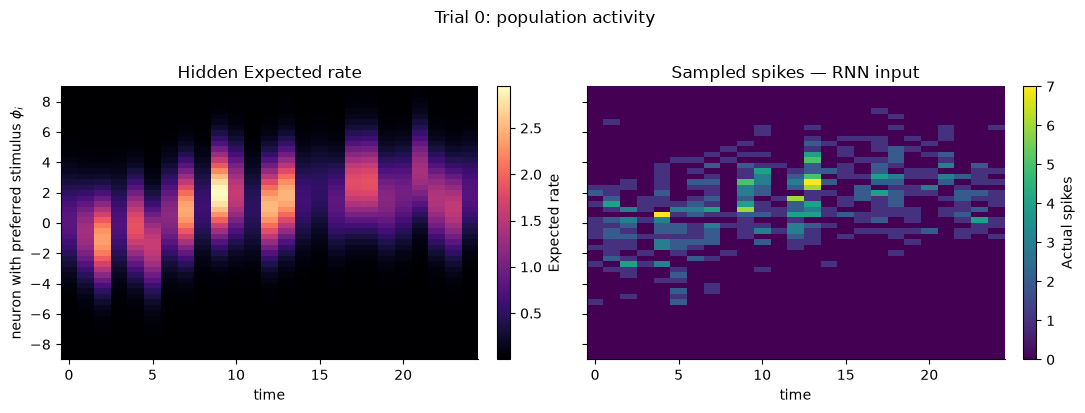

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
extent = (-0.5, len(t) - 0.5, phi[0], phi[-1])

rate_im = axes[0].imshow(
    expected_rate.T,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="magma",
    extent=extent,
)
spike_im = axes[1].imshow(
    spikes.T,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="viridis",
    extent=extent,
)

axes[0].set_title("Hidden Expected rate")
axes[1].set_title("Sampled spikes — RNN input")
for ax in axes:
    ax.set_xlabel("time")
axes[0].set_ylabel("neuron with preferred stimulus $\\phi_i$")
fig.colorbar(rate_im, ax=axes[0], fraction=0.046, pad=0.04, label="Expected rate")
fig.colorbar(spike_im, ax=axes[1], fraction=0.046, pad=0.04, label="Actual spikes")
fig.suptitle(f"Trial {trial_idx}: population activity", y=1.02)
fig.tight_layout()
plt.show()

### C. What the RNN can infer from its input

Population count is an observable proxy for the hidden Gain. The Instantaneous population estimate summarizes the stimulus location encoded by the current spikes without using temporal history.

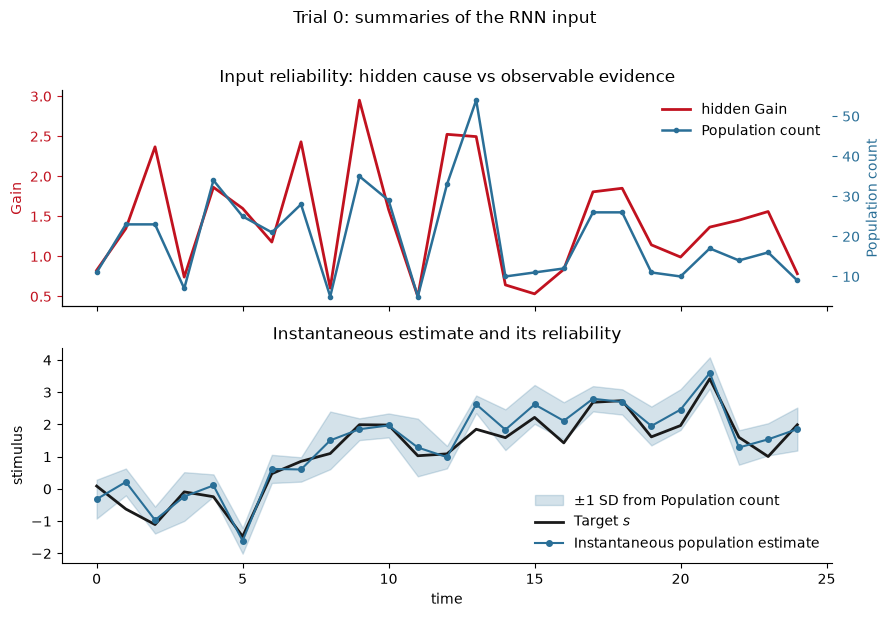

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

count_ax = axes[0].twinx()
gain_line = axes[0].plot(t, gain, color="#c1121f", lw=2, label="hidden Gain")
count_line = count_ax.plot(
    t,
    population_count,
    color="#2a6f97",
    lw=1.8,
    marker="o",
    ms=3,
    label="Population count",
)
axes[0].set_ylabel("Gain", color="#c1121f")
count_ax.set_ylabel("Population count", color="#2a6f97")
axes[0].tick_params(axis="y", colors="#c1121f")
count_ax.tick_params(axis="y", colors="#2a6f97")
axes[0].set_title("Input reliability: hidden cause vs observable evidence")
axes[0].legend(gain_line + count_line, [line.get_label() for line in gain_line + count_line], frameon=False)

axes[1].fill_between(
    t,
    population_estimate - population_sd,
    population_estimate + population_sd,
    color="#2a6f97",
    alpha=0.2,
    label="±1 SD from Population count",
)
axes[1].plot(t, s, color="#1a1a1a", lw=2, label="Target $s$")
axes[1].plot(
    t,
    population_estimate,
    color="#2a6f97",
    lw=1.5,
    marker="o",
    ms=4,
    label="Instantaneous population estimate",
)
axes[1].set_xlabel("time")
axes[1].set_ylabel("stimulus")
axes[1].set_title("Instantaneous estimate and its reliability")
axes[1].legend(frameon=False)

fig.suptitle(f"Trial {trial_idx}: summaries of the RNN input", y=1.02)
fig.tight_layout()
plt.show()

### D. Instantaneous estimate vs optimal estimate

The Instantaneous population estimate uses only the spikes at the current timestep. The Opt mean recursively combines that evidence with prior timesteps. Both are overlaid with the true Target; shaded regions show ±1 standard deviation.

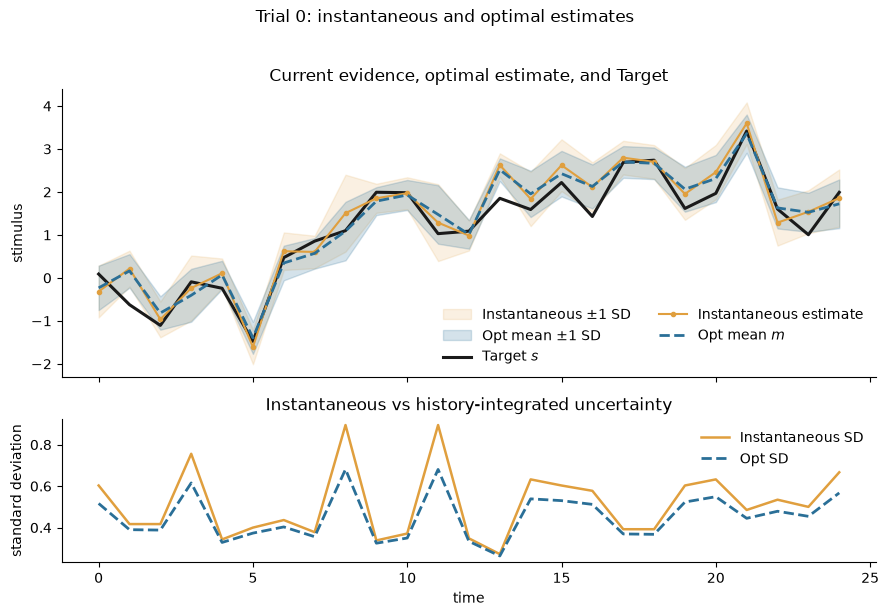

In [15]:
opt_sd = np.sqrt(opt_var)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

axes[0].fill_between(
    t,
    population_estimate - population_sd,
    population_estimate + population_sd,
    color="#e09f3e",
    alpha=0.15,
    label="Instantaneous ±1 SD",
)
axes[0].fill_between(
    t,
    m - opt_sd,
    m + opt_sd,
    color="#2a6f97",
    alpha=0.2,
    label="Opt mean ±1 SD",
)
axes[0].plot(t, s, color="#1a1a1a", lw=2.2, label="Target $s$")
axes[0].plot(
    t,
    population_estimate,
    color="#e09f3e",
    lw=1.5,
    marker="o",
    ms=3,
    label="Instantaneous estimate",
)
axes[0].plot(t, m, color="#2a6f97", lw=2, ls="--", label="Opt mean $m$")
axes[0].set_ylabel("stimulus")
axes[0].set_title("Current evidence, optimal estimate, and Target")
axes[0].legend(frameon=False, ncols=2)

axes[1].plot(t, population_sd, color="#e09f3e", lw=1.8, label="Instantaneous SD")
axes[1].plot(t, opt_sd, color="#2a6f97", lw=2, ls="--", label="Opt SD")
axes[1].set_xlabel("time")
axes[1].set_ylabel("standard deviation")
axes[1].set_title("Instantaneous vs history-integrated uncertainty")
axes[1].legend(frameon=False)

fig.suptitle(f"Trial {trial_idx}: instantaneous and optimal estimates", y=1.02)
fig.tight_layout()
plt.show()